# 9. Given a dataset representing a social network, create a graph and perform Social NetworkAnalysis (SNA) to find the most influential users using centrality measures like degree, closeness, and betwenness centrality.

use `networkx`

Sample Dataset:
    Follower Followed
0     Alice      Bob
1     Alice  Charlie
2       Bob    David
3   Charlie    David
4     David      Eve
5       Eve    Frank
6     Frank  Charlie
7    George    Alice
8    Hannah      Bob
9     Irene    David
10     Jack      Eve
11      Eve    Alice


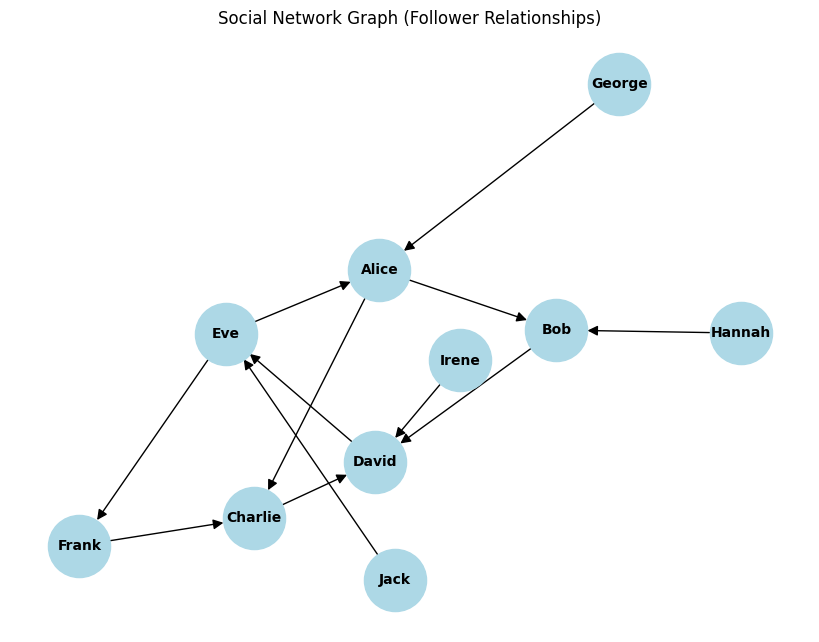


Centrality Measures:

         Degree Centrality  Closeness Centrality  Betweenness Centrality
Alice             0.444444              0.391304                0.212963
David             0.444444              0.473684                0.333333
Eve               0.444444              0.428571                0.361111
Bob               0.333333              0.360000                0.120370
Charlie           0.333333              0.360000                0.115741
Frank             0.222222              0.333333                0.050926
George            0.111111              0.000000                0.000000
Hannah            0.111111              0.000000                0.000000
Irene             0.111111              0.000000                0.000000
Jack              0.111111              0.000000                0.000000

Most Influential Users:
By Degree Centrality : Alice
By Closeness Centrality : David
By Betweenness Centrality: Eve


In [1]:
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt

edges = [ ('Alice', 'Bob'), ('Alice', 'Charlie'), ('Bob', 'David'), ('Charlie', 'David'), ('David', 'Eve'), ('Eve', 'Frank'), ('Frank', 'Charlie'), ('George', 'Alice'), ('Hannah', 'Bob'), ('Irene', 'David'), ('Jack', 'Eve'), ('Eve', 'Alice') ]

df = pd.DataFrame(edges, columns=['Follower', 'Followed'])
print("Sample Dataset:\n", df)

G= nx.DiGraph()
G.add_edges_from(edges)

plt.figure(figsize=(8,6))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=2000,
font_size=10, font_weight='bold', arrowsize=15)
plt.title("Social Network Graph (Follower Relationships)")
plt.show()

degree_centrality = nx.degree_centrality(G)
closeness_centrality = nx.closeness_centrality(G)
betweenness_centrality = nx.betweenness_centrality(G)

centrality_df = pd.DataFrame({
'Degree Centrality': degree_centrality,
'Closeness Centrality': closeness_centrality,
'Betweenness Centrality': betweenness_centrality
}).sort_values(by='Degree Centrality', ascending=False)
print("\nCentrality Measures:\n")
print(centrality_df)

print("\nMost Influential Users:")
print("By Degree Centrality :", centrality_df['Degree Centrality'].idxmax())
print("By Closeness Centrality :", centrality_df['Closeness Centrality'].idxmax())
print("By Betweenness Centrality:", centrality_df['Betweenness Centrality'].idxmax())